# Autoencoders

### Learning to compress by learning to reconstruct

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why squeezing an image through a narrow layer forces that layer to carry information, how a linear autoencoder relates to PCA at the same bottleneck size and what the non-linear version buys on top, what a two-number code space looks like, why corrupting the input produces better features than copying it, and how to turn reconstruction error into an anomaly score |
| **You should already know** | [Principal Component Analysis](../../06-dimensionality-reduction/01-principal-component-analysis/) · [The PyTorch training loop](../../07-neural-networks/03-the-same-net-in-pytorch/) |
| **Dataset** | Fashion-MNIST (28×28 greyscale, 10 classes; 12,000 training and 5,000 test images sampled from it) |
| **Runtime** | Four to six minutes on a laptop CPU, under two on a GPU |
| **Next** | [10-02 Variational autoencoders](../02-variational-autoencoders/) |

---

## 1. The idea

An autoencoder is a network trained to copy its input to its output. Written
down like that it sounds like the most pointless model in the book, and it would
be, except for one detail: somewhere in the middle there is a layer narrower
than the input, and everything has to pass through it.

That narrow layer is the **bottleneck**, and its contents are the **code**. The
first half of the network, the **encoder**, turns an image into a code. The
second half, the **decoder**, turns a code back into an image. If 784 pixels
have to fit through 32 numbers and come back out looking like the original, the
network has no choice but to decide what those 32 numbers are going to say.

```
  784 pixels  ->  encoder  ->  [ code ]  ->  decoder  ->  784 pixels
                                  32                        compare to the input
```

Two things are worth noticing before any code. First, no labels appear anywhere.
The input is the target, so the data supervises itself, and I can train on a pile
of unlabelled images. Second, this is compression with a learned codebook. A
general-purpose compressor like PNG has to work on any image ever made; an
autoencoder only has to work on the images it was trained on, and it spends its
whole capacity on them. That is why one trained on clothing is very good at
clothing and worthless on faces.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


In [2]:
train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]

N_TRAIN, N_TEST = 12_000, 5_000


def as_matrix(dataset, n_rows, seed=SEED):
    """Flatten a random subsample into one (rows, 784) tensor of floats in [0, 1].

    Every network here is dense, so the images may as well live as rows from the
    start. The subsampling is what keeps this notebook inside its runtime budget:
    I train a dozen small models, and doing that on all 60,000 images would take
    an hour for a conclusion I can reach on a fifth of them.
    """
    generator = torch.Generator().manual_seed(seed)
    picks = torch.randperm(len(dataset), generator=generator)[:n_rows].tolist()
    images = torch.stack([dataset[i][0] for i in picks]).view(len(picks), -1)
    labels = torch.tensor([dataset[i][1] for i in picks])
    return images, labels


X_train, y_train = as_matrix(train_set, N_TRAIN)
X_test, y_test = as_matrix(test_set, N_TEST)

print(f"training matrix {tuple(X_train.shape)}, test matrix {tuple(X_test.shape)}")
print(f"pixel range {X_train.min():.1f} to {X_train.max():.1f}")
print("class counts in the training sample:")
print(pd.Series(y_train.numpy()).value_counts().sort_index()
      .rename(index=dict(enumerate(CLASSES))).to_string())

training matrix (12000, 784), test matrix (5000, 784)
pixel range 0.0 to 1.0
class counts in the training sample:
T-shirt     1197
trouser     1180
pullover    1197
dress       1182
coat        1137
sandal      1217
shirt       1256
sneaker     1212
bag         1214
boot        1208


## 2. The architecture and the loss

Call the encoder $f$ and the decoder $g$. The loss is the squared difference
between what went in and what came out, averaged over the data:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\big\|\, x_i - g_\theta\!\left(f_\theta(x_i)\right) \big\|^2$$

There is no separate target. The input plays both parts.

**Why this forces the bottleneck to carry information.** The decoder sees the
code and nothing else. Any property of the image that fails to reach the code
is a property the decoder has to guess from scratch, and a wrong guess is a
permanent contribution to the loss that no amount of decoder training removes.
Gradient descent can only reduce that error by changing the encoder so the
missing property arrives in the code. So the bottleneck width is a budget, and
squared error decides the spending order: whatever removes the most squared
error per number is bought first. On images that is the coarse silhouette and
the overall brightness. Fine texture is last in the queue, which is why
small-code reconstructions come out blurred rather than wrong.

The bottleneck is doing all the work here. Make the code as wide as the input
and the cheapest solution is the identity function, which has zero loss and has
learned nothing.

In [3]:
class Autoencoder(nn.Module):
    """Dense encoder and decoder, mirrored, with a bottleneck of `latent` numbers."""

    def __init__(self, latent, n_in=784, widths=(256, 128)):
        super().__init__()
        wide, narrow = widths
        self.encoder = nn.Sequential(
            nn.Linear(n_in, wide), nn.ReLU(),
            nn.Linear(wide, narrow), nn.ReLU(),
            nn.Linear(narrow, latent),          # no activation: the code is unbounded
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, narrow), nn.ReLU(),
            nn.Linear(narrow, wide), nn.ReLU(),
            nn.Linear(wide, n_in), nn.Sigmoid(),  # pixels live in [0, 1], so does the output
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.decoder(self.encoder(x))


class LinearAutoencoder(nn.Module):
    """The same shape with every non-linearity removed. Section 3 needs this one."""

    def __init__(self, latent, n_in=784):
        super().__init__()
        # The biases matter: they are what lets this model absorb the mean image,
        # which is the job PCA's centring step does before it looks for directions.
        self.encoder = nn.Linear(n_in, latent)
        self.decoder = nn.Linear(latent, n_in)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.decoder(self.encoder(x))


count = lambda m: sum(p.numel() for p in m.parameters())
print(f"non-linear autoencoder, 32-number code : {count(Autoencoder(32)):,} parameters")
print(f"linear autoencoder,     32-number code : {count(LinearAutoencoder(32)):,} parameters")

non-linear autoencoder, 32-number code : 476,720 parameters
linear autoencoder,     32-number code : 50,992 parameters


In [4]:
def corrupt(x, sigma, generator=None):
    """Add Gaussian noise and clip back into the valid pixel range."""
    noise = torch.randn(x.shape, generator=generator, device=x.device) * sigma
    return (x + noise).clamp(0, 1)


def train_autoencoder(model, X, epochs=12, lr=2e-3, batch_size=128, noise=0.0):
    """The usual loop, with the input standing in as its own target.

    `noise` is the only thing that changes for section 4: fresh corruption is
    drawn every batch, but the target stays the clean image.
    """
    model = model.to(device)
    X = X.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []

    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(X), device=device)
        running = 0.0
        for start in range(0, len(X), batch_size):
            target = X[order[start:start + batch_size]]
            inputs = corrupt(target, noise) if noise else target
            optimiser.zero_grad()
            loss = loss_fn(model(inputs), target)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(target)
        history.append(running / len(X))
    return model, history


@torch.no_grad()
def per_image_mse(model, inputs, targets, batch_size=1000):
    """Squared error per pixel, one number per image. Kept per image because
    section 5 needs the whole distribution, not its mean."""
    model.eval()
    scores = []
    for start in range(0, len(inputs), batch_size):
        xb = inputs[start:start + batch_size].to(device)
        tb = targets[start:start + batch_size].to(device)
        scores.append(((model(xb) - tb) ** 2).mean(1).cpu())
    return torch.cat(scores)


@torch.no_grad()
def encode(model, X, batch_size=1000):
    model.eval()
    return torch.cat([model.encode(X[i:i + batch_size].to(device)).cpu()
                      for i in range(0, len(X), batch_size)])


@torch.no_grad()
def reconstruct(model, X):
    model.eval()
    return model(X.to(device)).cpu()

In [5]:
LATENT_SIZES = [2, 8, 32, 64]

started = time.perf_counter()
models, curves = {}, {}
for latent in LATENT_SIZES:
    torch.manual_seed(SEED)
    models[latent], curves[latent] = train_autoencoder(Autoencoder(latent), X_train)

sweep = pd.DataFrame({
    "code size": LATENT_SIZES,
    "compression": [f"{784 / latent:.0f}x" for latent in LATENT_SIZES],
    "train MSE": [curves[latent][-1] for latent in LATENT_SIZES],
    "test MSE": [per_image_mse(models[latent], X_test, X_test).mean().item()
                 for latent in LATENT_SIZES],
})
print(sweep.round(5).to_string(index=False))
print(f"\nfour autoencoders trained in {time.perf_counter() - started:.0f} seconds on {device}")

 code size compression  train MSE  test MSE
         2        392x    0.02927   0.02896
         8         98x    0.01658   0.01688
        32         24x    0.01659   0.01688
        64         12x    0.01593   0.01607

four autoencoders trained in 16 seconds on cuda


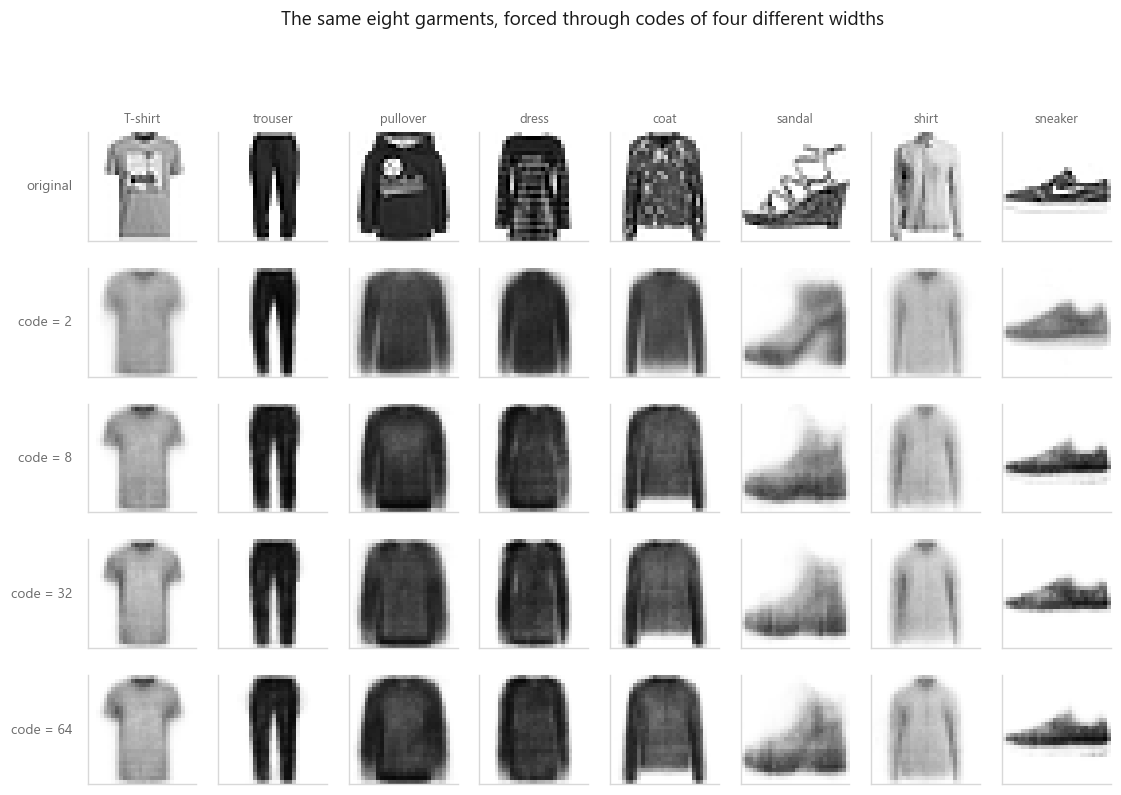

In [6]:
# One test image per class for the first eight classes, so every row of the grid
# shows the same garments and only the bottleneck changes.
picks = [int((y_test == c).nonzero(as_tuple=True)[0][0]) for c in range(8)]
originals = X_test[picks]

rows = [("original", originals)]
rows += [(f"code = {latent}", reconstruct(models[latent], originals))
         for latent in LATENT_SIZES]

fig, axes = plt.subplots(len(rows), 8, figsize=(12.0, 1.55 * len(rows)))
for r, (label, batch) in enumerate(rows):
    for c in range(8):
        ax = axes[r, c]
        ax.imshow(batch[c].view(28, 28), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if c == 0:
            ax.set_ylabel(label, fontsize=9, color=style.MUTED,
                          rotation=0, ha="right", va="center", labelpad=10)
        if r == 0:
            ax.set_title(CLASSES[int(y_test[picks[c]])], fontsize=8.5, color=style.MUTED)
fig.suptitle("The same eight garments, forced through codes of four different widths",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-reconstructions.png")

Read the grid from the bottom up and you watch information being dropped in
priority order. The wide codes keep the outline, the shading and most of the
print on the shirts. The narrow ones keep an outline and a rough brightness,
and where two garments have similar silhouettes they start to look like each
other. Nothing about that ordering was designed. It falls out of squared error
deciding what to buy first with the numbers it has.

## 3. Against PCA at the same bottleneck

PCA answers a question that sounds identical: which $k$-dimensional linear
subspace reconstructs the data with the smallest squared error? It has a closed
form answer, the top $k$ eigenvectors of the covariance matrix, and it takes a
second to compute.

So if I strip the activations out of the autoencoder, I have a model solving
PCA's exact problem by gradient descent instead of by eigendecomposition. The
result is known: a linear autoencoder trained on squared loss has its optimum
spanning the same subspace PCA finds. What it does *not* find is PCA's basis.
Any invertible mixing of the principal axes reconstructs the data identically,
and gradient descent has no reason to prefer the orthogonal, variance-ordered
one. It finds the subspace, not the axes.

Two things follow that I can check rather than believe. A linear autoencoder
should never beat PCA at the same bottleneck, so any gap is an optimisation gap
and not a modelling one. And the non-linear autoencoder should beat both, by
some amount I have no way of guessing in advance, because its code can index a
curved surface through the data rather than a flat slice of it. Whether that
curvature is worth much at two numbers or at sixty-four is exactly the sort of
thing to measure.

In [7]:
from sklearn.decomposition import PCA

X_train_np = X_train.numpy()
X_test_np = X_test.numpy()

pca = PCA(n_components=max(LATENT_SIZES), random_state=SEED).fit(X_train_np)


def pca_reconstruct(X, k):
    """Project onto the first k components and come back. Fitting once and
    truncating is exact, because the components are nested."""
    scores = (X - pca.mean_) @ pca.components_[:k].T
    return scores @ pca.components_[:k] + pca.mean_


linear_models = {}
for latent in LATENT_SIZES:
    torch.manual_seed(SEED)
    # Higher learning rate than the deep model: this one has to actually converge
    # for the comparison to say anything, and it is small enough to take it.
    linear_models[latent], _ = train_autoencoder(
        LinearAutoencoder(latent), X_train, epochs=12, lr=5e-3)

comparison = pd.DataFrame({
    "code size": LATENT_SIZES,
    "PCA": [float(((pca_reconstruct(X_test_np, k) - X_test_np) ** 2).mean())
            for k in LATENT_SIZES],
    "linear autoencoder": [per_image_mse(linear_models[k], X_test, X_test).mean().item()
                           for k in LATENT_SIZES],
    "non-linear autoencoder": [per_image_mse(models[k], X_test, X_test).mean().item()
                               for k in LATENT_SIZES],
})
comparison["non-linear advantage"] = (
    1 - comparison["non-linear autoencoder"] / comparison["PCA"])

print("held-out reconstruction error, mean squared error per pixel:")
print(comparison.round(5).to_string(index=False))

held-out reconstruction error, mean squared error per pixel:
 code size     PCA  linear autoencoder  non-linear autoencoder  non-linear advantage
         2 0.04659             0.04669                 0.02896               0.37840
         8 0.02675             0.02713                 0.01688               0.36886
        32 0.01534             0.01624                 0.01688              -0.10059
        64 0.01057             0.01156                 0.01607              -0.52001


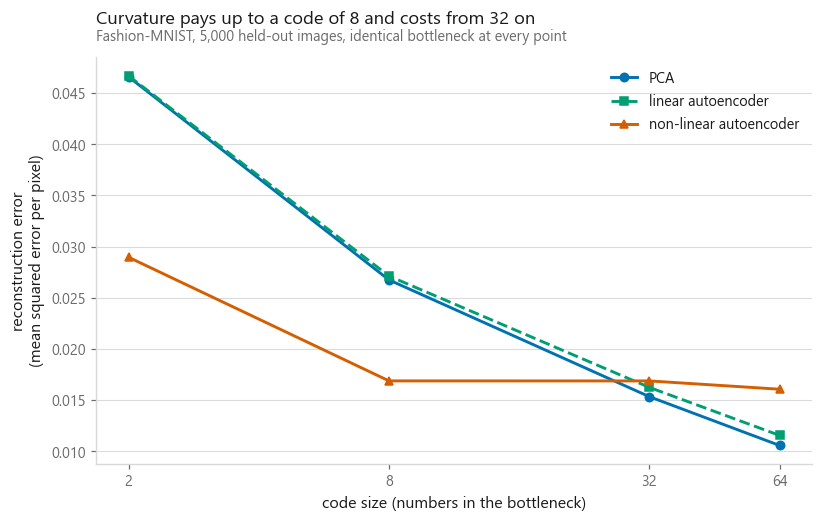

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot(comparison["code size"], comparison["PCA"],
        marker=style.MARKERS[0], color=style.PALETTE[0], label="PCA")
ax.plot(comparison["code size"], comparison["linear autoencoder"],
        marker=style.MARKERS[1], color=style.PALETTE[2], linestyle="--",
        label="linear autoencoder")
ax.plot(comparison["code size"], comparison["non-linear autoencoder"],
        marker=style.MARKERS[2], color=style.HIGHLIGHT, label="non-linear autoencoder")
ax.set_xscale("log", base=2)
ax.set_xticks(LATENT_SIZES, [str(k) for k in LATENT_SIZES])
ax.set_xlabel("code size (numbers in the bottleneck)")
ax.set_ylabel("reconstruction error\n(mean squared error per pixel)")
ax.legend()
# The caption reads the crossover off the table rather than off the expectation.
pays = comparison.loc[comparison["non-linear advantage"] > 0, "code size"]
costs = comparison.loc[comparison["non-linear advantage"] <= 0, "code size"]
if len(pays) and len(costs):
    verdict = (f"Curvature pays up to a code of {pays.max()} "
               f"and costs from {costs.min()} on")
elif len(pays):
    verdict = "Curvature pays at every code size measured"
else:
    verdict = "Curvature costs at every code size measured"
style.title(ax, verdict,
            "Fashion-MNIST, 5,000 held-out images, identical bottleneck at every point")
style.save(fig, FIG / "fig-02-autoencoder-vs-pca.png")

I predicted the non-linear autoencoder would beat both. It did that on half the
sweep and lost the other half. It cut PCA's error by 37.8% at a 2-number code and
by 36.9% at 8, then came in 10.1% worse at 32 and 52.0% worse at 64. The chart is
a picture of where curvature stops paying, not where it starts.

The two lines say why. PCA improves all the way across, 0.04659 down to 0.01057,
because every extra eigenvector is a genuinely new direction of variance. The
non-linear autoencoder flattens out: 0.01688 at code 8, 0.01688 again at 32,
0.01607 at 64, which is the same plateau the training table showed earlier. It is
not that curvature stops existing at a wide bottleneck. It is that this model
stops using the extra width, and what runs out first is the training budget, not
the model class. A curved surface can always match a flat one. This one was not
trained far enough to.

The dashed line is the theory check. If the linear autoencoder sits on top of
PCA then gradient descent found the optimum that eigendecomposition found
directly; if it sits above, it simply has not finished converging, and the fix
is more steps rather than a different model. It cannot sit below. It sits above
at every code size, in the only direction theory allows, and close enough at the
fourth decimal to look converged.

"Looks converged" is worth testing, because the loss is not the claim. The claim
was about the subspace, so I check the subspace directly. Take the rows of the
linear encoder's weight matrix, orthonormalise them, and measure how much of
PCA's top-$k$ basis lies inside that span. A value of 1 means the two models
found the same subspace using different coordinates for it.

In [9]:
overlaps = []
for latent in LATENT_SIZES:
    W = linear_models[latent].encoder.weight.detach().cpu().numpy()   # (latent, 784)
    basis, _ = np.linalg.qr(W.T)                                     # orthonormal span of W
    projected = basis.T @ pca.components_[:latent].T
    overlaps.append(float((projected ** 2).sum() / latent))

print("how much of PCA's subspace the linear autoencoder found (1.0 = the same subspace):")
for latent, value in zip(LATENT_SIZES, overlaps):
    print(f"  code size {latent:>2} : {value:.4f}")

how much of PCA's subspace the linear autoencoder found (1.0 = the same subspace):
  code size  2 : 0.0888
  code size  8 : 0.3042
  code size 32 : 0.5618
  code size 64 : 0.6308


None of them got there. The overlap reads 0.0888 at code 2, 0.3042 at 8, 0.5618
at 32 and 0.6308 at 64, against the 1.0 that would mean the same subspace. The
best of the four found under two thirds of PCA's span and the narrowest found
under a tenth. The theory is a statement about the optimum; these encoders are
not at it.

The loss had already said otherwise, which is the part worth keeping. At code 64
the linear autoencoder's held-out error was 0.01156 against PCA's 0.01057, a gap
in the third decimal that reads as converged from the loss column alone, while
the subspace it had actually found overlapped PCA's by 0.6308. A model can sit
near the optimal *value* of a squared loss and a long way from the optimal
*solution*, because the surface is close to flat in the directions that separate
them. When there is a way to check the claim you made rather than the number that
usually tracks it, check the claim.

### What two numbers look like

A code of size two is useless for reconstruction and perfect for looking at.
Here is every held-out image placed at its own code, coloured by the label the
model never saw, with PCA's first two components beside it for scale.

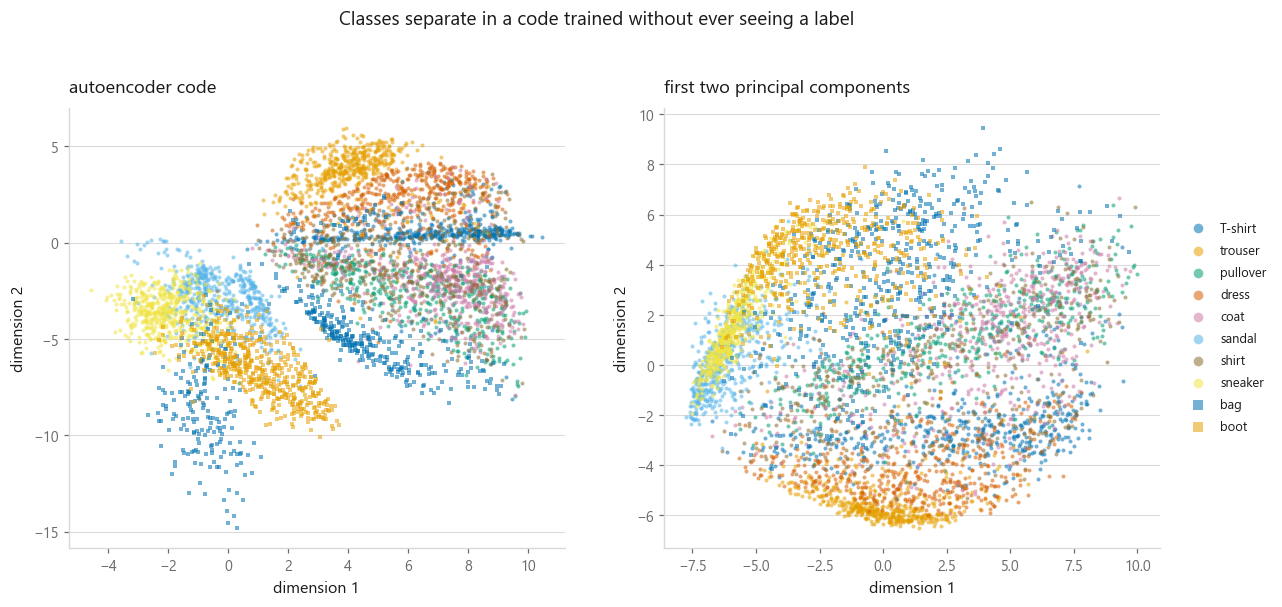

In [10]:
Z_ae = encode(models[2], X_test).numpy()
Z_pca = (X_test_np - pca.mean_) @ pca.components_[:2].T

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.2))
for ax, (name, coords) in zip(axes, [("autoencoder code", Z_ae),
                                     ("first two principal components", Z_pca)]):
    for c in range(10):
        mask = (y_test == c).numpy()
        # Ten classes into an eight-colour palette, so the last two are separated
        # by marker shape instead. Colour is never the only channel here.
        ax.scatter(coords[mask, 0], coords[mask, 1], s=7, alpha=0.55, linewidths=0,
                   color=style.PALETTE[c % 8], marker=style.MARKERS[c // 8],
                   label=CLASSES[c])
    ax.set_xlabel("dimension 1"); ax.set_ylabel("dimension 2")
    style.title(ax, name)

axes[1].legend(loc="center left", bbox_to_anchor=(1.03, 0.5), fontsize=8.5,
               markerscale=2.4, labelspacing=0.7)
fig.suptitle("Classes separate in a code trained without ever seeing a label",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-latent-space.png")

In [11]:
from sklearn.neighbors import KNeighborsClassifier

Z_ae_train = encode(models[2], X_train).numpy()
Z_pca_train = (X_train_np - pca.mean_) @ pca.components_[:2].T

knn_ae = KNeighborsClassifier(15).fit(Z_ae_train, y_train.numpy()).score(Z_ae, y_test.numpy())
knn_pca = KNeighborsClassifier(15).fit(Z_pca_train, y_train.numpy()).score(Z_pca, y_test.numpy())

print("15-nearest-neighbour accuracy using only the two coordinates:")
print(f"  autoencoder code : {knn_ae:.4f}")
print(f"  PCA components   : {knn_pca:.4f}")
print(f"  guessing         : {1 / 10:.4f}")

15-nearest-neighbour accuracy using only the two coordinates:
  autoencoder code : 0.6758
  PCA components   : 0.5358
  guessing         : 0.1000


Neither map is a clustering algorithm and neither was told that classes exist.
The structure is there because garments that reconstruct through similar codes
are garments that look alike, and looking alike is most of what a Fashion-MNIST
label means. Footwear ends up in one region because a sandal, a sneaker and a
boot share a wide, low silhouette; the shirt-shaped classes pile into another
region and overlap badly, which is the same complaint the classification
notebooks make about this dataset.

The nearest-neighbour numbers above put a figure on how much of the class
signal survives the squeeze to two dimensions. Compare them to a classifier
trained on all 784 pixels and they look poor, which is the honest way to read
them: two numbers is an absurd budget, and the point is that anything at all
survives.

## 4. Denoising

Plain reconstruction has a weakness that only becomes obvious once you widen the
bottleneck: the task rewards remembering, and remembering is not the same as
understanding. With enough capacity the network can behave like a lookup table,
routing each image to a code that identifies it without ever learning what a
sleeve is.

A **denoising autoencoder** removes that option. Corrupt the input, keep the
target clean, and train on

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\big\|\, x_i - g_\theta\!\left(f_\theta(\tilde{x}_i)\right) \big\|^2, \qquad \tilde{x}_i = x_i + \varepsilon_i$$

with fresh noise $\varepsilon_i$ drawn every time the image comes round. Copying
the input now scores badly, because copying the input copies the noise. To do
well the network has to work out which pixels were plausible and which were
damaged, and the only way to know that is to have learned how pixels in a
garment relate to their neighbours. That is the argument for corruption turning
a memorisation task into a task about structure, and it predicts a better code
rather than only a better output. The linear probe below is where that prediction
gets tested.

In [12]:
NOISE = 0.5
generator = torch.Generator().manual_seed(SEED)
X_test_noisy = corrupt(X_test, NOISE, generator=generator)

torch.manual_seed(SEED)
denoiser, denoiser_curve = train_autoencoder(Autoencoder(32), X_train, noise=NOISE)

plain = models[32]                       # same architecture, same epochs, clean input
print("recovering the clean image from a noisy one, mean squared error per pixel:")
print(f"  noisy input itself, no model : "
      f"{((X_test_noisy - X_test) ** 2).mean().item():.5f}")
print(f"  plain autoencoder            : "
      f"{per_image_mse(plain, X_test_noisy, X_test).mean().item():.5f}")
print(f"  denoising autoencoder        : "
      f"{per_image_mse(denoiser, X_test_noisy, X_test).mean().item():.5f}")

recovering the clean image from a noisy one, mean squared error per pixel:
  noisy input itself, no model : 0.11759
  plain autoencoder            : 0.05681
  denoising autoencoder        : 0.02239


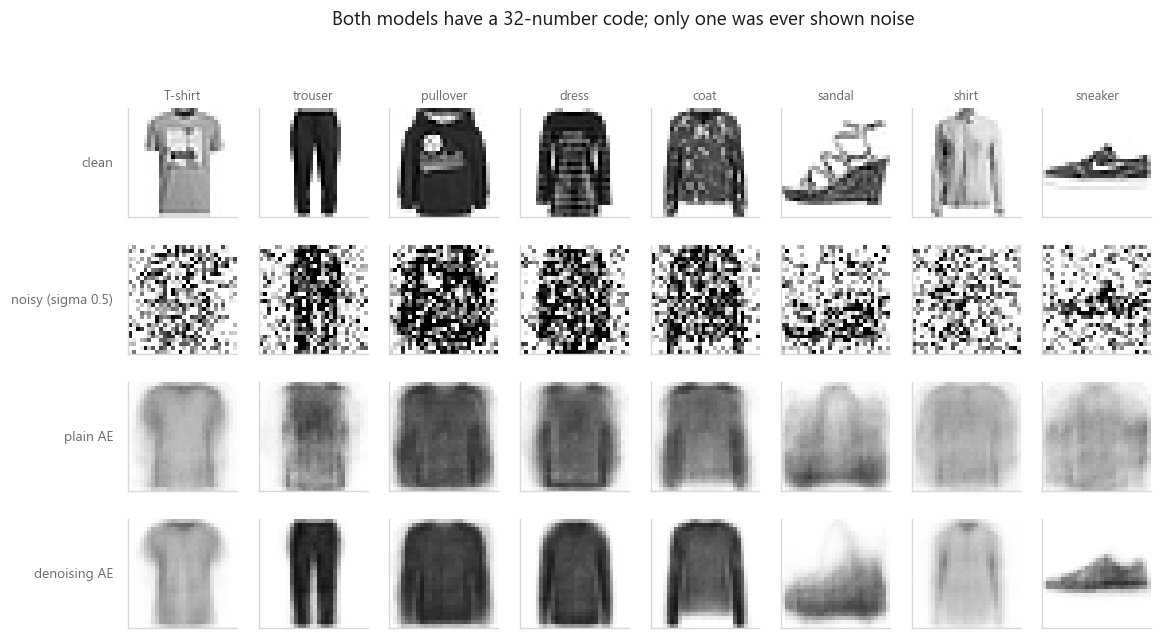

In [13]:
noisy_batch = X_test_noisy[picks]
rows = [
    ("clean", originals),
    (f"noisy (sigma {NOISE})", noisy_batch),
    ("plain AE", reconstruct(plain, noisy_batch)),
    ("denoising AE", reconstruct(denoiser, noisy_batch)),
]

fig, axes = plt.subplots(len(rows), 8, figsize=(12.0, 1.55 * len(rows)))
for r, (label, batch) in enumerate(rows):
    for c in range(8):
        ax = axes[r, c]
        ax.imshow(batch[c].view(28, 28), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if c == 0:
            ax.set_ylabel(label, fontsize=9, color=style.MUTED,
                          rotation=0, ha="right", va="center", labelpad=10)
        if r == 0:
            ax.set_title(CLASSES[int(y_test[picks[c]])], fontsize=8.5, color=style.MUTED)
fig.suptitle("Both models have a 32-number code; only one was ever shown noise",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-denoising.png")

The claim that denoising produces better features, rather than merely a better
denoiser, needs a separate test. The standard one is a **linear probe**: freeze
the encoder, take the codes it produces for clean images, and fit multinomial
logistic regression on top. A linear model cannot invent structure, so whatever
accuracy it reaches is structure the code had already laid out. Same code size,
same architecture, same number of epochs for both, with PCA at 32 components in
as a reference point: an untrained rotation of the pixels, which both learned
codes ought to be able to beat.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


def linear_probe(codes_train, codes_test):
    scaler = StandardScaler().fit(codes_train)
    classifier = LogisticRegression(max_iter=2000).fit(
        scaler.transform(codes_train), y_train.numpy())
    return classifier.score(scaler.transform(codes_test), y_test.numpy())


probes = {
    "PCA, 32 components": linear_probe((X_train_np - pca.mean_) @ pca.components_[:32].T,
                                       (X_test_np - pca.mean_) @ pca.components_[:32].T),
    "plain autoencoder, 32": linear_probe(encode(plain, X_train).numpy(),
                                          encode(plain, X_test).numpy()),
    "denoising autoencoder, 32": linear_probe(encode(denoiser, X_train).numpy(),
                                              encode(denoiser, X_test).numpy()),
}
print("logistic regression on frozen 32-number codes, held-out accuracy:")
for name, accuracy in probes.items():
    print(f"  {name:<27}: {accuracy:.4f}")

logistic regression on frozen 32-number codes, held-out accuracy:
  PCA, 32 components         : 0.8096
  plain autoencoder, 32      : 0.8014
  denoising autoencoder, 32  : 0.7836


The probe says the opposite of the prediction. PCA at 32 components scored
0.8096, the plain autoencoder 0.8014, and the denoising autoencoder 0.7836. The
denoising code came last of the three, below a plain autoencoder trained on clean
images and below PCA, which is a rotation of the pixels with no training in it at
all. Neither learned code beat the reference point.

So corruption bought a denoiser and not a code. The same encoder that recovers a
clean garment from a noisy one at 0.02239 against the plain model's 0.05681 lays
its thirty-two numbers out worse for a linear classifier. That is not a
contradiction once you notice the two tasks reward different things. Removing
noise rewards knowing what a plausible neighbourhood of pixels looks like; a
linear probe rewards putting the classes in positions a hyperplane can separate.
Nothing makes one of those produce the other.

One probe, at one code size, one noise level and one dataset, does not refute the
general claim that denoising improves representations. It does refute taking the
claim on trust here, which is the whole reason for running the probe rather than
quoting the denoising number and moving on.

## 5. Reconstruction error as an anomaly score

Everything so far treats the reconstruction error as a training signal. It is
also a measurement, and a useful one, because a trained autoencoder is only good
at what it was trained on. Feed it something outside that distribution and the
decoder produces the nearest familiar thing it knows how to draw, which leaves a
large residual. So:

$$\text{score}(x) = \big\| x - g\!\left(f(x)\right) \big\|^2$$

A high score means unfamiliar. This is the whole method, and its appeal is that
it needs no examples of the thing being detected, which is exactly the situation
in fraud, manufacturing defects and machine faults.

To test it honestly I drop one class from training entirely, train on the other
nine, and score held-out images of all ten. The model has never spent a single
gradient step on the missing class.

In [15]:
from sklearn.metrics import roc_auc_score

HELD_OUT = 8                                       # bag
seen = y_train != HELD_OUT
torch.manual_seed(SEED)
sentry, _ = train_autoencoder(Autoencoder(32), X_train[seen])

scores = per_image_mse(sentry, X_test, X_test).numpy()
is_unseen = (y_test == HELD_OUT).numpy()

threshold = np.quantile(scores[~is_unseen], 0.95)
auc = roc_auc_score(is_unseen, scores)

print(f"trained on {int(seen.sum()):,} images from nine classes, "
      f"{CLASSES[HELD_OUT]} withheld")
print(f"mean error, nine seen classes : {scores[~is_unseen].mean():.5f}")
print(f"mean error, {CLASSES[HELD_OUT]:<21}: {scores[is_unseen].mean():.5f}")
print(f"ROC AUC                       : {auc:.4f}")
print(f"at the 95th-percentile threshold, {CLASSES[HELD_OUT]} caught: "
      f"{(scores[is_unseen] > threshold).mean():.3f}")

trained on 10,786 images from nine classes, bag withheld
mean error, nine seen classes : 0.01637
mean error, bag                  : 0.04047
ROC AUC                       : 0.9420
at the 95th-percentile threshold, bag caught: 0.621


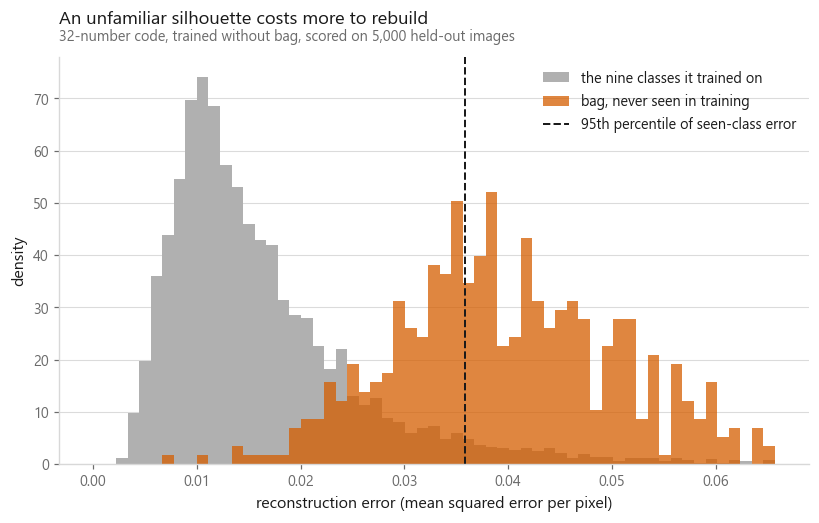

In [16]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
edges = np.linspace(0, float(np.quantile(scores, 0.995)), 60)
ax.hist(scores[~is_unseen], bins=edges, density=True, color=style.NEUTRAL,
        label="the nine classes it trained on")
ax.hist(scores[is_unseen], bins=edges, density=True, color=style.HIGHLIGHT,
        alpha=0.75, label=f"{CLASSES[HELD_OUT]}, never seen in training")
ax.axvline(threshold, color=style.INK, linestyle="--", linewidth=1.3,
           label="95th percentile of seen-class error")
ax.set_xlabel("reconstruction error (mean squared error per pixel)")
ax.set_ylabel("density")
ax.legend()
style.title(ax, "An unfamiliar silhouette costs more to rebuild",
            f"32-number code, trained without {CLASSES[HELD_OUT]}, scored on 5,000 held-out images")
style.save(fig, FIG / "fig-05-anomaly-scores.png")

One held-out class is one data point, and picking a flattering one would be easy.
So here is the same experiment for all ten, with a smaller training sample and
fewer epochs to keep it quick. The spread across rows is the honest description
of the method.

In [17]:
started = time.perf_counter()
records = []
for held_out in range(10):
    keep = (y_train != held_out).nonzero(as_tuple=True)[0][:6000]
    torch.manual_seed(SEED)
    watcher, _ = train_autoencoder(Autoencoder(32), X_train[keep], epochs=6)
    class_scores = per_image_mse(watcher, X_test, X_test).numpy()
    records.append({"withheld class": CLASSES[held_out],
                    "ROC AUC": roc_auc_score((y_test == held_out).numpy(), class_scores)})

sweep_auc = pd.DataFrame(records).sort_values("ROC AUC", ascending=False)
print(sweep_auc.round(3).to_string(index=False))
print(f"\nten models in {time.perf_counter() - started:.0f} seconds; "
      f"0.5 would be a coin flip")

withheld class  ROC AUC
           bag    0.951
       trouser    0.798
        sandal    0.778
          boot    0.754
         dress    0.695
       sneaker    0.624
       T-shirt    0.605
      pullover    0.568
          coat    0.563
         shirt    0.538

ten models in 11 seconds; 0.5 would be a coin flip


That table is the part worth carrying away. Reconstruction error detects a class
as anomalous only when unfamiliar and hard-to-rebuild happen to mean the same
thing. A silhouette unlike anything in training scores well. A class whose
neighbours were all in the training set does not, because a model that has seen
T-shirts, pullovers and coats can rebuild a shirt perfectly well without ever
having been shown one.

The failure is not a bug in the method, it is the method's definition of
anomalous showing through. Before deploying this anywhere, ask whether the
faults you care about are ones a model trained on healthy data would find
difficult to draw. Sometimes they plainly are. Sometimes the defect is a small
change in a texture the model reproduces from habit, and the score never moves.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You need compression, denoising, or an outlier score, and you have plenty of unlabelled examples of normal |
| **Avoid it when** | You want to sample new images. A plain autoencoder's code space has holes, and decoding a point you invented usually produces mush. That is what [10-02](../02-variational-autoencoders/) fixes |
| **The bottleneck** | Narrower than the input, always. Equal width lets the network learn the identity and learn nothing |
| **The loss** | MSE for real-valued inputs, binary cross-entropy for inputs in [0, 1]. Match the output activation to the range |
| **Versus PCA** | Drop the activations and you are doing PCA by gradient descent. Curvature paid at codes 2 and 8 here and cost at 32 and 64, so where the crossover falls is a fact about the training budget as much as about the data |
| **Denoising** | Corrupt the input, keep the target clean, redraw the noise every batch. Costs one line and improved the output. It made the code worse on the probe, 0.7836 against a plain autoencoder's 0.8014 and PCA's 0.8096 |
| **Anomalies** | Score with reconstruction error, threshold on a percentile of the training distribution, and check per class before trusting it |
| **Watch out** | A wide code plus a deep decoder can memorise. Low reconstruction error is not evidence that the code means anything; probe it |

## What to remember

1. An autoencoder copies its input through a narrow layer. The narrowness is the
   entire mechanism, because anything the code drops is an error the decoder
   cannot repair.
2. Squared error sets the spending order for a limited code: silhouette and
   brightness first, texture last. Blurred reconstructions are that ordering
   made visible.
3. PCA's subspace is where a linear autoencoder's squared loss is optimised, and
   these four did not reach it: the overlap topped out at 0.6308 and started at
   0.0888, while the loss column looked converged. It cannot beat PCA, so any
   shortfall is an optimisation problem, and the loss will not tell you how big
   one is.
4. The non-linear version buys curvature. The figure and the table above say how
   much that was worth at each bottleneck size on this dataset.
5. Two-dimensional codes separate classes the model was never shown, because
   reconstructing a garment well and recognising it use overlapping information.
6. Denoising improved the output and made the code worse. It recovered clean
   images at 0.02239 against the plain model's 0.05681, then probed at 0.7836
   against the plain model's 0.8014 and PCA's 0.8096. Run the probe before
   believing that a training trick improved the representation.
7. Reconstruction error is an anomaly score that needs no anomalies to train on,
   and it works exactly as well as the assumption that unfamiliar things are
   hard to redraw. Test that assumption per class.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [10-02 Variational autoencoders](../02-variational-autoencoders/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Autoencoder` `#RepresentationLearning` `#AnomalyDetection`
`#PCA` `#PyTorch` `#FashionMNIST` `#UnsupervisedLearning` `#MachineLearning`
`#Python` `#MLTutorial` `#AI`